# unalabeled dataset

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==========================
# STEP 1: Load your datasets
# ==========================
df1 = pd.read_csv(r"E:\2nd year lab work\Machine learnign and techniques\Comodity sales\89cement data .csv")
df2 = pd.read_csv(r"E:\2nd year lab work\Machine learnign and techniques\dimnesional data sets\supply_chain_dataset1.csv")
df3 = pd.read_csv(r"E:\2nd year lab work\Machine learnign and techniques\construction dataset\construction_project_performance_dataset.csv")

print("Dataset Shapes:")
print("DF1:", df1.shape)
print("DF2:", df2.shape)
print("DF3:", df3.shape)

# =======================================
# STEP 2: Combine datasets row-wise
# =======================================
combined_df = pd.concat([df1, df2, df3], axis=0, ignore_index=True)

print("\nCombined Dataset Shape:", combined_df.shape)

# =======================================
# STEP 3: Select only numeric columns
# =======================================
X_unlabeled = combined_df.select_dtypes(include=["int64", "float64"]).copy()

print("\nNumeric Columns:")
print(X_unlabeled.columns)

# =======================================
# STEP 4: Remove constant columns
# =======================================
X_unlabeled = X_unlabeled.loc[:, X_unlabeled.nunique() > 1]

print("\nAfter removing constant columns:", X_unlabeled.shape)

# =======================================
# STEP 5: Handle missing values
# =======================================
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X_unlabeled)

# =======================================
# STEP 6: Standardize data
# =======================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# =======================================
# STEP 7: Remove low variance features
# =======================================
selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(X_scaled)

print("\nShape after variance threshold:", X_filtered.shape)

Dataset Shapes:
DF1: (999, 14)
DF2: (91250, 15)
DF3: (10000, 15)

Combined Dataset Shape: (102249, 44)

Numeric Columns:
Index(['Production', 'Sales ', 'demand', 'population', 'gdp', 'disbusment',
       'interestrate', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Units_Sold',
       'Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point',
       'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag',
       'Stockout_Flag', 'Demand_Forecast', 'Temperature (°C)', 'Humidity (%)',
       'Vibration_Level (Hz)', 'Material_Usage (kg)',
       'Energy_Consumption (kWh)', 'Worker_Count', 'Task_Progress (%)',
       'Safety_Incidents', 'Resource_Utilization (%)', 'Risk_Score',
       'Simulation_Accuracy (%)'],
      dtype='object')

After removing constant columns: (102249, 27)

Shape after variance threshold: (102249, 27)


# K-Means


Original Shape: (102249, 27)
Reduced Shape after PCA: (102249, 5)

Explained Variance Ratio:
[0.18217548 0.07498518 0.07246365 0.05793641 0.05525845]
Total Variance Retained: 0.4428191733259378

Silhouette Score: 0.22497398996248005

Clustered Output:
   Production  Sales   demand  population       gdp  disbusment  interestrate  \
0       347.0   322.0   346.0       122.4  182277.0    60314.00         10.25   
1       306.0   285.0   338.0       122.5  181018.0    61213.92         10.33   
2       236.0   245.0   276.0       122.6  179759.0    62113.83         10.42   
3       234.0   212.0   245.0       122.8  178500.0    63013.75         10.50   
4       296.0   289.0   312.0       122.9  177354.0    63913.67         10.58   

   Units_Sold  Inventory_Level  Supplier_Lead_Time_Days  ...  \
0         NaN              NaN                      NaN  ...   
1         NaN              NaN                      NaN  ...   
2         NaN              NaN                      NaN  ...   
3   

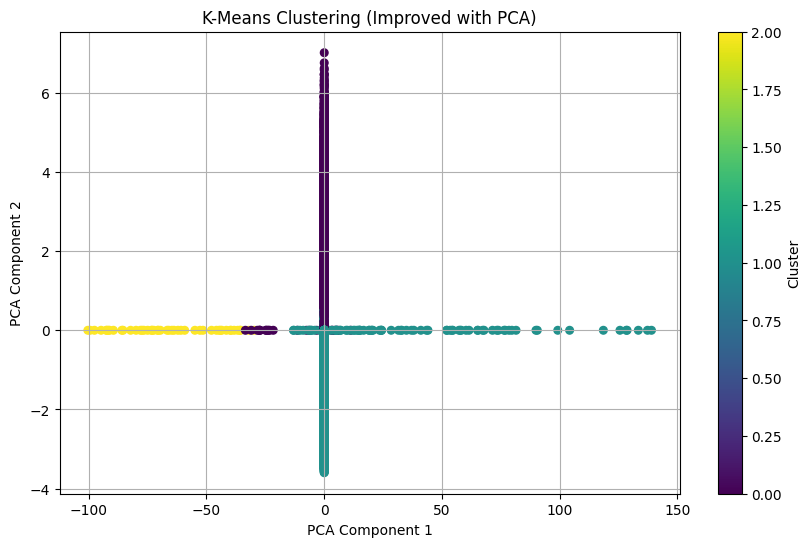

In [14]:
pca_cluster = PCA(n_components=5)
X_reduced = pca_cluster.fit_transform(X_filtered)

print("\nOriginal Shape:", X_filtered.shape)
print("Reduced Shape after PCA:", X_reduced.shape)

print("\nExplained Variance Ratio:")
print(pca_cluster.explained_variance_ratio_)
print("Total Variance Retained:", np.sum(pca_cluster.explained_variance_ratio_))

# =======================================
# STEP 9: Apply K-Means clustering
# =======================================
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_reduced)

# =======================================
# STEP 10: Evaluate clustering
# =======================================
sil_score = silhouette_score(X_reduced, cluster_labels)

print("\nSilhouette Score:", sil_score)

# =======================================
# STEP 11: Save output
# =======================================
X_output = X_unlabeled.copy()
X_output["Cluster"] = cluster_labels

print("\nClustered Output:")
print(X_output.head())

X_output.to_csv("combined_kmeans_output.csv", index=False)

print("\nK-Means clustering completed successfully!")

# =======================================
# STEP 12: 2D Visualization using PCA
# =======================================
pca_visual = PCA(n_components=2)
X_pca = pca_visual.fit_transform(X_filtered)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="viridis",
    s=30
)

plt.title("K-Means Clustering (Improved with PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

# Hierarchical

   Production  Sales   demand  population       gdp  disbusment  interestrate  \
0       347.0   322.0   346.0       122.4  182277.0    60314.00         10.25   
1       306.0   285.0   338.0       122.5  181018.0    61213.92         10.33   
2       236.0   245.0   276.0       122.6  179759.0    62113.83         10.42   
3       234.0   212.0   245.0       122.8  178500.0    63013.75         10.50   
4       296.0   289.0   312.0       122.9  177354.0    63913.67         10.58   

   Units_Sold  Inventory_Level  Supplier_Lead_Time_Days  ...  \
0         NaN              NaN                      NaN  ...   
1         NaN              NaN                      NaN  ...   
2         NaN              NaN                      NaN  ...   
3         NaN              NaN                      NaN  ...   
4         NaN              NaN                      NaN  ...   

   Vibration_Level (Hz)  Material_Usage (kg)  Energy_Consumption (kWh)  \
0                   NaN                  NaN          

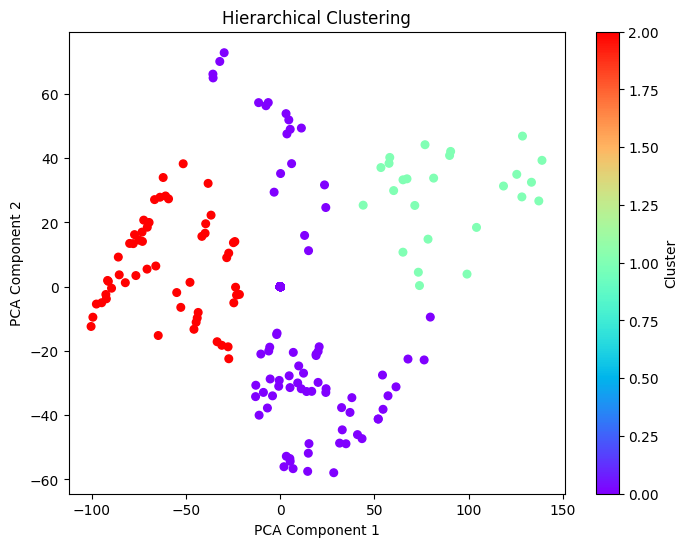

In [15]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X_unlabeled)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_sample = X_scaled[:1000]
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)
cluster_labels = hierarchical.fit_predict(X_sample)
hierarchical_output = X_unlabeled.iloc[:1000].copy()
hierarchical_output["Hierarchical_Cluster"] = cluster_labels
print(hierarchical_output.head())
hierarchical_output.to_csv("combined_hierarchical_output_sample.csv", index=False)
print("Hierarchical clustering completed successfully on sampled data!")

#Graphical representation
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce sampled data to 2D
pca = PCA(n_components=2)
X_sample_pca = pca.fit_transform(X_sample)

# Plot Hierarchical clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_sample_pca[:, 0], X_sample_pca[:, 1], c=cluster_labels, cmap='rainbow', s=30)
plt.title("Hierarchical Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# DBSCAN

Shape after removing constant columns: (102249, 27)
Shape after variance threshold: (102249, 27)
Original Shape: (102249, 27)
Reduced Shape after PCA: (102249, 5)
Explained Variance Ratio:
[0.18217548 0.07498518 0.07246365 0.05793641 0.05525845]
Total Variance Retained: 0.4428191733259378

DBSCAN Output (first 5 rows):
   Production  Sales   demand  population       gdp  disbusment  interestrate  \
0       347.0   322.0   346.0       122.4  182277.0    60314.00         10.25   
1       306.0   285.0   338.0       122.5  181018.0    61213.92         10.33   
2       236.0   245.0   276.0       122.6  179759.0    62113.83         10.42   
3       234.0   212.0   245.0       122.8  178500.0    63013.75         10.50   
4       296.0   289.0   312.0       122.9  177354.0    63913.67         10.58   

   Units_Sold  Inventory_Level  Supplier_Lead_Time_Days  ...  \
0         NaN              NaN                      NaN  ...   
1         NaN              NaN                      NaN  ...   


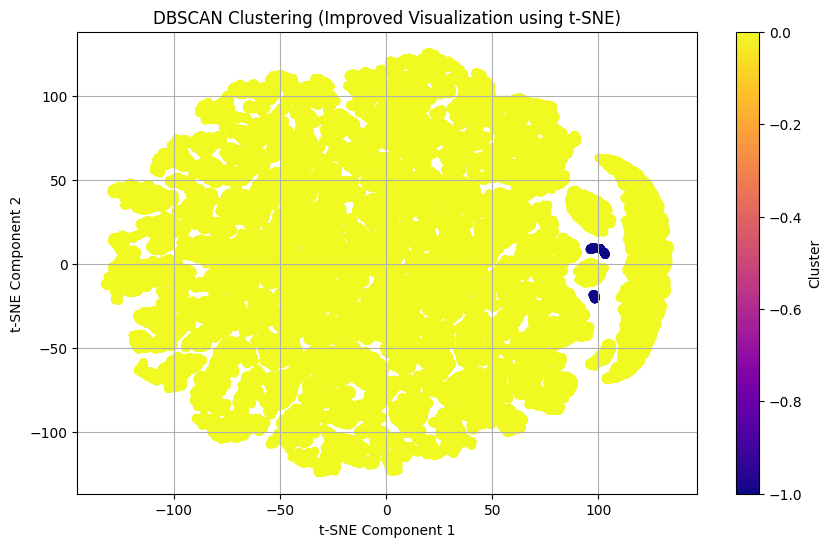

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE

# =======================================
# STEP 1: Select only numeric columns
# =======================================
X_unlabeled = combined_df.select_dtypes(include=["int64", "float64"]).copy()

# =======================================
# STEP 2: Remove constant columns
# =======================================
X_unlabeled = X_unlabeled.loc[:, X_unlabeled.nunique() > 1]

print("Shape after removing constant columns:", X_unlabeled.shape)

# =======================================
# STEP 3: Handle missing values
# =======================================
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X_unlabeled)

# =======================================
# STEP 4: Standardize data
# =======================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# =======================================
# STEP 5: Remove low variance features
# =======================================
selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(X_scaled)

print("Shape after variance threshold:", X_filtered.shape)

# =======================================
# STEP 6: PCA for dimensionality reduction
# =======================================
pca_cluster = PCA(n_components=5)
X_reduced = pca_cluster.fit_transform(X_filtered)

print("Original Shape:", X_filtered.shape)
print("Reduced Shape after PCA:", X_reduced.shape)

print("Explained Variance Ratio:")
print(pca_cluster.explained_variance_ratio_)
print("Total Variance Retained:", np.sum(pca_cluster.explained_variance_ratio_))

# =======================================
# STEP 7: Apply DBSCAN
# =======================================
dbscan = DBSCAN(
    eps=1.5,          # increased for better density grouping
    min_samples=10    # more stable cluster formation
)

cluster_labels = dbscan.fit_predict(X_reduced)

# =======================================
# STEP 8: Save output
# =======================================
X_output = X_unlabeled.copy()
X_output["DBSCAN_Cluster"] = cluster_labels

print("\nDBSCAN Output (first 5 rows):")
print(X_output.head())

X_output.to_csv("combined_dbscan_output.csv", index=False)

# =======================================
# STEP 9: Cluster distribution
# =======================================
unique, counts = np.unique(cluster_labels, return_counts=True)

print("\nCluster Distribution:")
for u, c in zip(unique, counts):
    if u == -1:
        print(f"Noise Points (-1): {c}")
    else:
        print(f"Cluster {u}: {c}")

print("\nDBSCAN clustering completed successfully!")

# =======================================
# STEP 10: Better visualization using t-SNE
# =======================================
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_reduced)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=cluster_labels,
    cmap="plasma",
    s=30
)

plt.title("DBSCAN Clustering (Improved Visualization using t-SNE)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()